In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('../Datasets/extrovert/train.csv')
test = pd.read_csv('../Datasets/extrovert/test.csv')

In [51]:
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [52]:
df.shape

(18524, 9)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [54]:
df.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


In [55]:
df['Drained_after_socializing'].value_counts()

Drained_after_socializing
No     13313
Yes     4062
Name: count, dtype: int64

In [56]:
df['Personality'] = df['Personality'].map({'Extrovert':1, 'Introvert': 0})
df['Stage_fear'] = df['Stage_fear'].map({'No':0, 'Yes':1})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'No':0, 'Yes':1})

In [78]:
test['Stage_fear'] = test['Stage_fear'].map({'No':0, 'Yes':1})
test['Drained_after_socializing'] = test['Drained_after_socializing'].map({'No':0, 'Yes':1})

In [57]:
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0.0,6.0,4.0,0.0,15.0,5.0,1
1,1,1.0,0.0,7.0,3.0,0.0,10.0,8.0,1
2,2,6.0,1.0,1.0,0.0,NaN,3.0,0.0,0
3,3,3.0,0.0,7.0,3.0,0.0,11.0,5.0,1
4,4,1.0,0.0,4.0,4.0,0.0,13.0,NaN,1


In [58]:
df['Personality']

0        1
1        1
2        0
3        1
4        1
        ..
18519    1
18520    1
18521    0
18522    0
18523    1
Name: Personality, Length: 18524, dtype: int64

In [59]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

<Axes: >

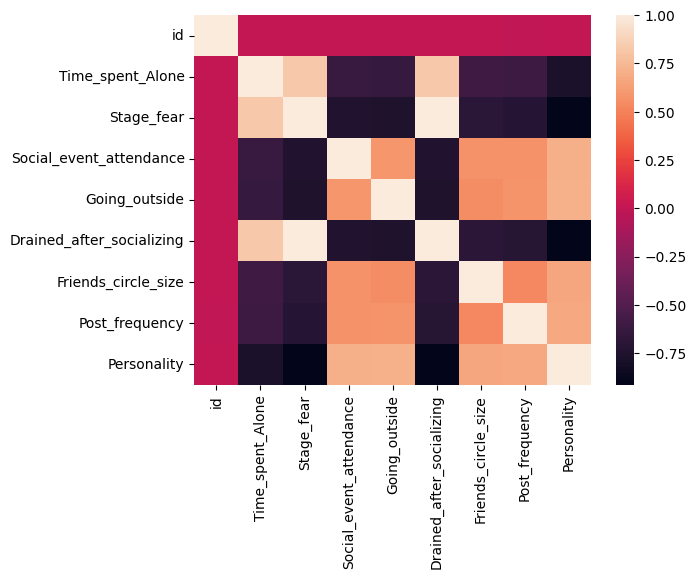

In [60]:
sns.heatmap(df.corr(numeric_only=True))

In [63]:
df = df.apply(lambda x: x.fillna(x.mean()))
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0.0,6.0,4.0,0.000000,15.0,5.000000,1
1,1,1.0,0.0,7.0,3.0,0.000000,10.0,8.000000,1
2,2,6.0,1.0,1.0,0.0,0.233784,3.0,0.000000,0
3,3,3.0,0.0,7.0,3.0,0.000000,11.0,5.000000,1
4,4,1.0,0.0,4.0,4.0,0.000000,13.0,4.982097,1


In [79]:
test = test.apply(lambda x: x.fillna(x.mean()))

In [64]:
df.isnull().sum()

id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [62]:
df.shape

(18524, 9)

<Axes: >

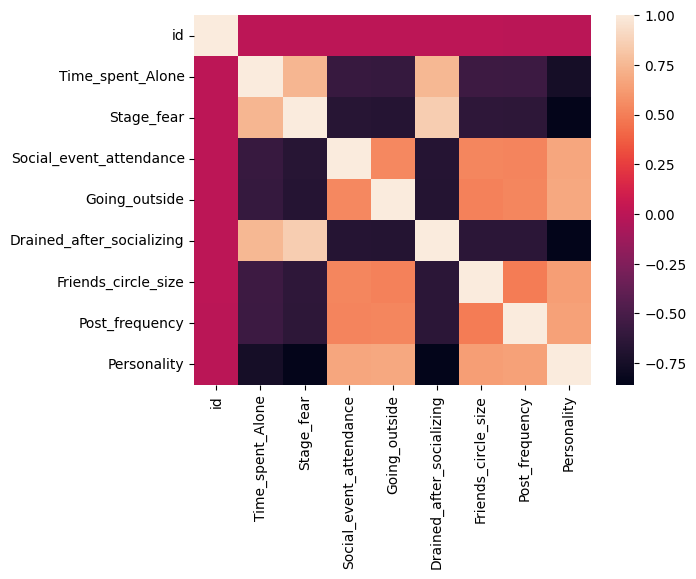

In [65]:
sns.heatmap(df.corr(numeric_only=True))

In [71]:
X = df.iloc[:,1:-1]
y = df.iloc[:,-1]

In [72]:
X.shape

(18524, 7)

In [73]:
y.shape

(18524,)

In [74]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [75]:
rf.fit(X,y)

RandomForestClassifier()

In [88]:
temp = test.iloc[:,1:]

In [89]:
temp.shape

(6175, 7)

In [92]:
y_pred = rf.predict(temp)
y_pred

array([1, 0, 1, ..., 1, 1, 0])

In [99]:
import numpy as np

submit_pred = pd.DataFrame({
    'id' : test['id'],
    'Personality' : np.where(y_pred == 1,'Extrovert','Introvert')
})

In [100]:
submit_pred.shape

(6175, 2)

In [101]:
submit_pred.to_csv('prediction.csv',index=False)